This notebook contains all query results turned into a respective graph, for analysis. Only a few of the graphs are included in the report (excluding the appendix) and discussed.

"How does average traffic flow (number or speed of vehicles per unit of time) correlate with accident frequency on specific road segments?"

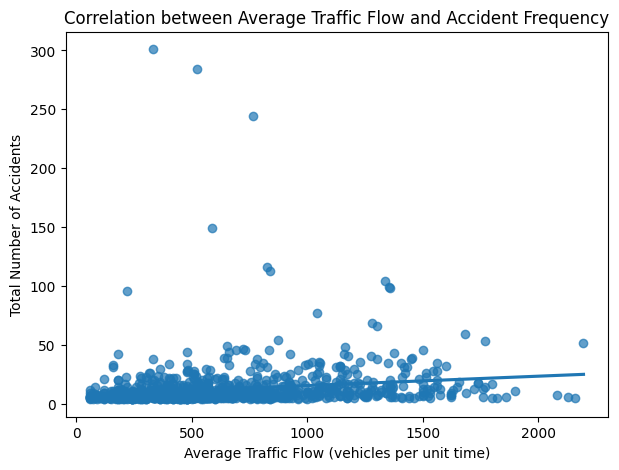

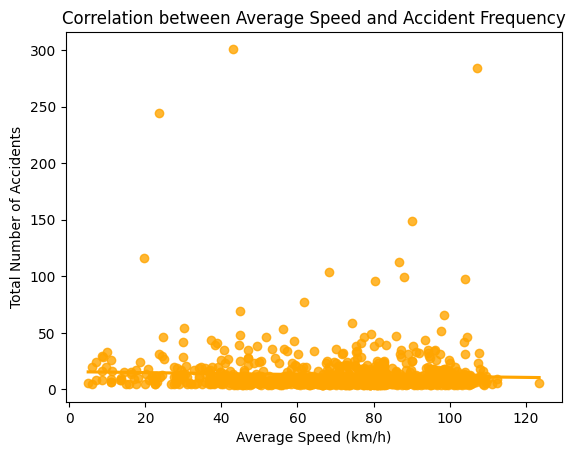

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query1-result.csv"
df = pd.read_csv(file_path)

plt.figure(figsize=(7,5))
sns.regplot(data=df, x="averageFlow", y="totalAccidents", ci=None, scatter_kws={'alpha':0.7})
plt.title("Correlation between Average Traffic Flow and Accident Frequency")
plt.xlabel("Average Traffic Flow (vehicles per unit time)")
plt.ylabel("Total Number of Accidents")
plt.show()

sns.regplot(data=df, x="averageSpeed", y="totalAccidents", ci=None, color="orange")
plt.title("Correlation between Average Speed and Accident Frequency")
plt.xlabel("Average Speed (km/h)")
plt.ylabel("Total Number of Accidents")
plt.show()

"What is the distribution of accident severity... near complex traffic infrastructure, such as road segments typed as 'Bridge' or 'Tunnel', or roads that have 'Stop' signs (B7)?"

  infrastructureLabel         severityLabel  count
0              Bridge  Material Damage Only   2875
1              Bridge                Injury    493
2              Bridge                 Fatal      7
3              Tunnel  Material Damage Only    358
4              Tunnel                Injury     75


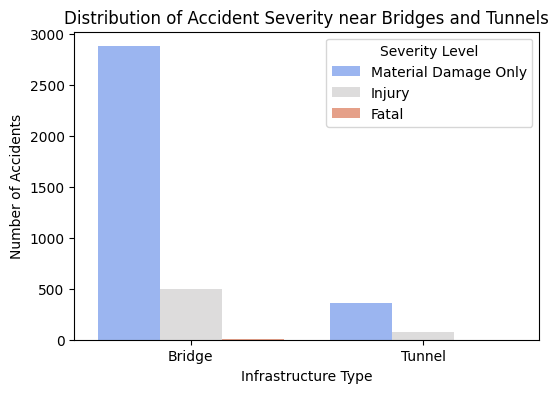

  infrastructureLabel         severityLabel  count  percentage
0              Bridge  Material Damage Only   2875   85.185185
1              Bridge                Injury    493   14.607407
2              Bridge                 Fatal      7    0.207407
3              Tunnel  Material Damage Only    358   82.298851
4              Tunnel                Injury     75   17.241379
5              Tunnel                 Fatal      2    0.459770


/var/folders/mn/2zksnfhn3sd0z2dd3qrld3200000gn/T/ipykernel_60247/1539669297.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(percentage=100 * x["count"] / x["count"].sum()))


In [11]:
file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query2-result.csv"
df = pd.read_csv(file_path)
print(df.head())

plt.figure(figsize=(6,4))
sns.barplot(
    data=df, 
    x="infrastructureLabel", 
    y="count", 
    hue="severityLabel", 
    palette="coolwarm"
)
plt.title("Distribution of Accident Severity near Bridges and Tunnels")
plt.xlabel("Infrastructure Type")
plt.ylabel("Number of Accidents")
plt.legend(title="Severity Level")
plt.show()

df_percent = (
    df.groupby("infrastructureLabel")
      .apply(lambda x: x.assign(percentage=100 * x["count"] / x["count"].sum()))
      .reset_index(drop=True)
)
print(df_percent)

"What vehicle types (e.g., Car, Bicycle, Truck) are most frequently involved in accidents on traffic:Residential and traffic:LivingStreet roads?"

                                        vehicleClass  accidentCount
0  http://www.semanticweb.org/nicol/ontologies/20...          69882
1  http://www.semanticweb.org/nicol/ontologies/20...          19532
2  http://www.semanticweb.org/nicol/ontologies/20...          13019
3  http://www.semanticweb.org/nicol/ontologies/20...           1920
4  http://www.semanticweb.org/nicol/ontologies/20...           1717


/var/folders/mn/2zksnfhn3sd0z2dd3qrld3200000gn/T/ipykernel_60247/2541317192.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


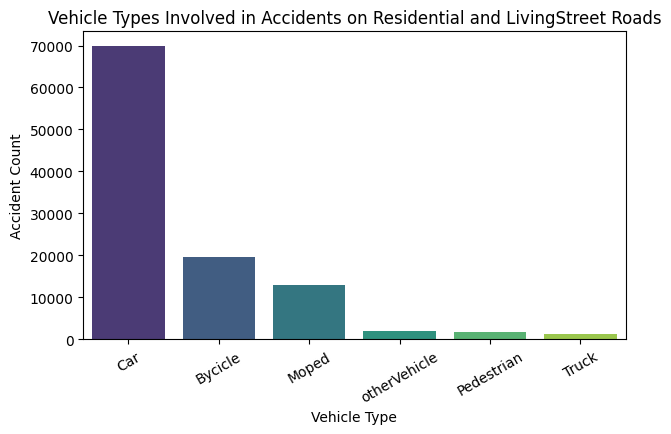

In [16]:
file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query3-result.csv"
df = pd.read_csv(file_path)
print(df.head())

df["vehicleLabel"] = df["vehicleClass"].apply(lambda uri: uri.split("/")[-1])
plt.figure(figsize=(7,4))
sns.barplot(
    data=df, 
    x="vehicleLabel", 
    y="accidentCount", 
    palette="viridis"
)
plt.title("Vehicle Types Involved in Accidents on Residential and LivingStreet Roads")
plt.xlabel("Vehicle Type")
plt.ylabel("Accident Count")
plt.xticks(rotation=30)
plt.show()

"What sections of roads with a speed limit over 30 km/h have the most accidents involving pedestrians or cyclists on wet or snowy road surfaces?"

                                                road              roadName  \
0  http://www.semanticweb.org/nicol/ontologies/20...     Goudenregenstraat   
1  http://www.semanticweb.org/nicol/ontologies/20...                  Spui   
2  http://www.semanticweb.org/nicol/ontologies/20...  Nieuwe Ebbingestraat   
3  http://www.semanticweb.org/nicol/ontologies/20...   Hertog Aalbrechtweg   
4  http://www.semanticweb.org/nicol/ontologies/20...            Steijnlaan   

   vulnerableUserAccidents  
0                       15  
1                        9  
2                        7  
3                        6  
4                        6  


/var/folders/mn/2zksnfhn3sd0z2dd3qrld3200000gn/T/ipykernel_60247/2274651905.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


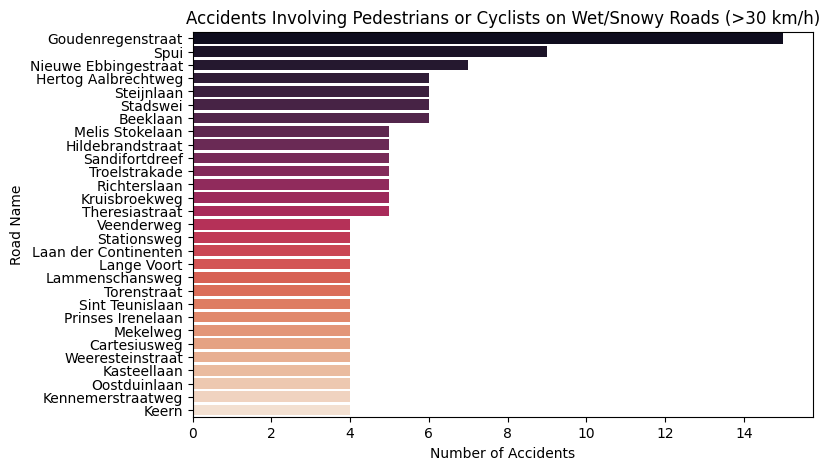

In [19]:
file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query4-result.csv"
df = pd.read_csv(file_path)
print(df.head())

df_sorted = df.sort_values("vulnerableUserAccidents", ascending=False).head(30)

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_sorted,
    y="roadName",
    x="vulnerableUserAccidents",
    palette="rocket"
)
plt.title("Accidents Involving Pedestrians or Cyclists on Wet/Snowy Roads (>30 km/h)")
plt.xlabel("Number of Accidents")
plt.ylabel("Road Name")
plt.show()

"Which specific road segments were 'persistent accident hotspots', appearing in the top 20 most dangerous segments for multiple years (2022, 2023, 2024)?"

                                                road            roadName  \
0  http://www.semanticweb.org/nicol/ontologies/20...        Rijksweg A15   
1  http://www.semanticweb.org/nicol/ontologies/20...        Rijksweg A15   
2  http://www.semanticweb.org/nicol/ontologies/20...        Ringweg-West   
3  http://www.semanticweb.org/nicol/ontologies/20...        Ringweg-Oost   
4  http://www.semanticweb.org/nicol/ontologies/20...  John F Kennedylaan   

   totalAccidents  yearsWithAccidents  
0            2779                   3  
1             621                   3  
2             301                   3  
3             284                   3  
4             280                   3  


/var/folders/mn/2zksnfhn3sd0z2dd3qrld3200000gn/T/ipykernel_60247/3669386798.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


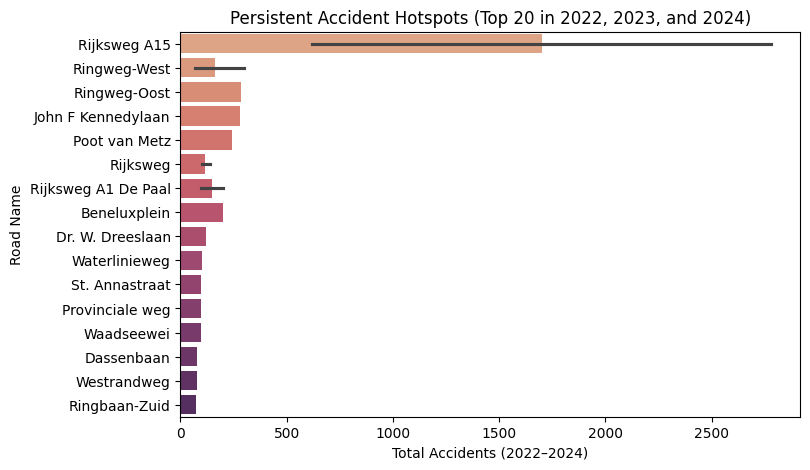

In [29]:
file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query5-result.csv"
df = pd.read_csv(file_path)
print(df.head())

df_persistent = df[df["yearsWithAccidents"] == 3]

plt.figure(figsize=(8,5))
sns.barplot(
    data=df_persistent.sort_values("totalAccidents", ascending=False).head(30),
    y="roadName",
    x="totalAccidents",
    palette="flare"
)
plt.title("Persistent Accident Hotspots (Top 20 in 2022, 2023, and 2024)")
plt.xlabel("Total Accidents (2022–2024)")
plt.ylabel("Road Name")
plt.show()


"What are the most common types of traffic signs (e.g., speed limits, priority signs) present on road segments where accidents occur?"

  rvvCode                signLabel  accidentCount
0      B6            Give way sign          89121
1      A1              Speed limit          58764
2     G11              Cycle route          53529
3      D2  Keep right/left of sign          53173
4      B1            Priority road          41827


/var/folders/mn/2zksnfhn3sd0z2dd3qrld3200000gn/T/ipykernel_60247/514951612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


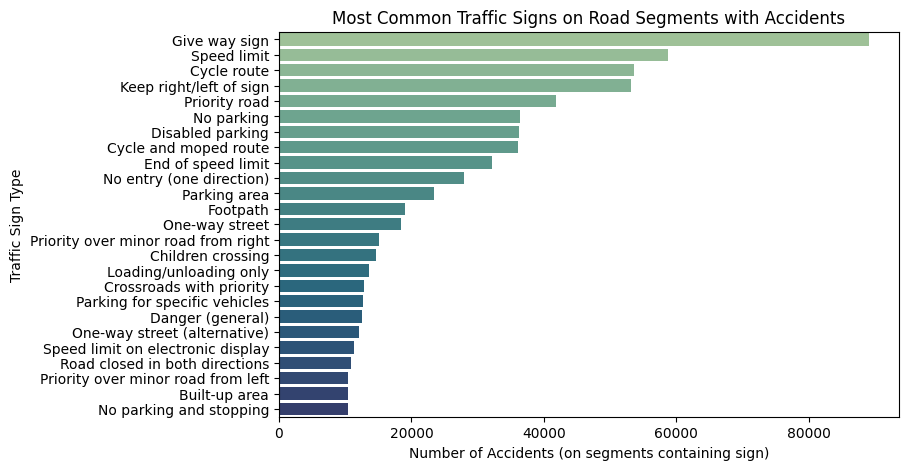

In [28]:
file_path = "/Users/louisbattle/Documents/University/BscAI/Year 2/Period 1/KAD/project/data viz/query results/query6-result.csv"
df = pd.read_csv(file_path)
print(df.head())

plt.figure(figsize=(8,5))
sns.barplot(
    data=df.sort_values("accidentCount", ascending=False).head(25),
    y="signLabel",
    x="accidentCount",
    palette="crest"
)
plt.title("Most Common Traffic Signs on Road Segments with Accidents")
plt.xlabel("Number of Accidents (on segments containing sign)")
plt.ylabel("Traffic Sign Type")
plt.show()